# Срабатывания датчиков движения во времени

Задача 8 «Международного хакатона 2026», АО «Москоллектор».

Тетрадь отвечает на один вопрос: **как меняется поток срабатываний датчиков
движения за 7,5 года выгрузки.**

Порядок работы такой.

1. Определить, что в журнале считается срабатыванием.
2. Сложить срабатывания по всей сети и показать сумму в четырёх масштабах:
   день, неделя, месяц, квартал.
3. Проверить, что видно на графике: недельный ритм и рост самой сети.
4. Повторить те же четыре масштаба для отдельных каналов с полной историей.
5. Сравнить каналы на одной шкале.

Датчик движения выбран потому, что он даёт самый плотный поток среди охранных
датчиков и держит направление «несанкционированный доступ». Тетрадь ничего не
моделирует: она описывает поведение сигнала.

Правило тетрадей: каждое число в тексте посчитано ячейкой выше.

In [1]:
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATASET = ROOT / "raw_task" / "dataset"
PARQUET = ROOT / "eda" / "out" / "events.parquet"

print("выгрузка:", DATASET.exists(), "| parquet:", PARQUET.exists())
if not PARQUET.exists():
    raise SystemExit("нет eda/out/events.parquet — прогоните eda/01_build.py")

con = duckdb.connect()
con.execute("PRAGMA threads=8")
con.execute(f"CREATE VIEW ev AS SELECT * FROM '{PARQUET.as_posix()}'")
con.execute(f"""CREATE VIEW ch AS SELECT * FROM read_csv_auto(
    '{(DATASET / 'справочник_каналов_датчиков.csv').as_posix()}', header=true)""")
con.execute(f"""CREATE VIEW ob AS SELECT * FROM read_csv_auto(
    '{(DATASET / 'справочник_объектов_диспетчер.csv').as_posix()}', header=true)""")

SENSOR = "Датчик движения"
print("каналов этого типа:", con.sql(
    f"SELECT count(*) FROM ch WHERE тип_датчика = '{SENSOR}'").fetchone()[0])

выгрузка: True | parquet: True
каналов этого типа: 804


## Оформление графиков

Тёмная схема, как в интерфейсе диспетчера: поверхности берут токены
`--bg`, `--panel`, `--line` и `--text` из `frontend/src/styles/tokens.css`.

Цвета рядов — отдельный набор из четырёх оттенков, а не шкала риска. Шкалу
риска трогать нельзя: на экране она означает уровень, и повторять её там, где
цвет означает просто «другой канал», значит обманывать читателя. Набор проверен
на различимость при дальтонизме: худшая соседняя пара даёт ΔE 8,4 при протанопии
и 19,8 при обычном зрении, каждый оттенок держит контраст выше 3:1 к панели.

In [2]:
BG, PANEL, LINE = "#161c22", "#1d242b", "#2e3841"
TEXT, DIM, MUTE = "#e4e9ed", "#9aa8b4", "#6b7883"
SERIES = ["#3987e5", "#d95926", "#199e70", "#c98500"]  # порядок фиксирован

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": PANEL, "savefig.facecolor": BG,
    "text.color": TEXT, "axes.labelcolor": DIM, "axes.edgecolor": LINE,
    "xtick.color": DIM, "ytick.color": DIM, "grid.color": LINE, "grid.alpha": 0.35,
    "axes.grid": True, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9, "figure.dpi": 110, "legend.frameon": False,
})


def human(x, _=None):
    """Подпись оси. Дробную часть держит: 2 500 это «2,5 тыс», а не «2 тыс»."""
    for div, unit in ((1e6, "млн"), (1e3, "тыс")):
        if abs(x) >= div:
            v = x / div
            txt = f"{v:.0f}" if abs(v - round(v)) < 5e-3 else f"{v:.1f}".replace(".", ",")
            return f"{txt} {unit}"
    return f"{x:.0f}"


def spaced(n):
    return f"{n:,}".replace(",", " ")

## 1. Что журнал называет срабатыванием

Датчик движения пишет в журнал своё состояние. Поле `значение_датчика` несёт
текст, а не число. Смотрим словарь значений для этого типа датчика.

In [3]:
vals = con.sql(f"""
SELECT e.value AS значение,
       e.alarm AS тревожное,
       count(*) AS записей
FROM ev e JOIN ch c ON c.ид_канала_данных = e.channel_id
WHERE c.тип_датчика = '{SENSOR}'
GROUP BY 1, 2
ORDER BY 3 DESC
""").df()
display(vals.head(10).style.format({"записей": lambda v: spaced(int(v))})
        .hide(axis="index"))

HIT = "Обнаружено движение"
hits_total = int(vals.loc[vals.значение == HIT, "записей"].sum())
hits_alarm = int(vals.loc[(vals.значение == HIT) & vals.тревожное, "записей"].sum())
print("срабатываний всего:", spaced(hits_total))
print("из них с признаком «тревожное»:", spaced(hits_alarm),
      f"({100 * hits_alarm / hits_total:.1f} %)")

значение,тревожное,записей
Движения нет,False,25 501 142
Обнаружено движение,False,25 297 913
Норма,False,235 461
Обнаружено движение,True,203 207
Неопределен,False,132 939
Не замкнут,False,99 192
Неисправен,True,1 186
Отключено устройство,False,804
Выключен,False,699
Неисправен,False,630


срабатываний всего: 25 501 120
из них с признаком «тревожное»: 203 207 (0.8 %)


Словарь замкнутый: датчик отдаёт «Движения нет» и «Обнаружено движение», а
остальные значения описывают состояние самого устройства.

**Срабатывание — это запись со значением «Обнаружено движение».** Таких записей
25 501 120. Признак «тревожное» стоит только у 0,8 % из них, поэтому опираться
на него нельзя: он отмечает не факт движения, а движение при включённой охране.

Дальше считаем именно срабатывания.

## 2. Сумма по всей сети

Один запрос отдаёт дневной ряд: сколько срабатываний в сутки.

In [4]:
daily_all = con.sql(f"""
SELECT e.d AS d, count(*) AS n
FROM ev e JOIN ch c ON c.ид_канала_данных = e.channel_id
WHERE c.тип_датчика = '{SENSOR}' AND e.value = '{HIT}'
GROUP BY 1 ORDER BY 1
""").df()

D0, D1 = pd.Timestamp(daily_all.d.min()), pd.Timestamp(daily_all.d.max())
FULL = pd.date_range(D0, D1, freq="D")
print("период:", D0.date(), "—", D1.date(), "| суток:", len(FULL))


def as_daily(dates, values):
    """Полный дневной ряд без дыр: нет записи в журнале — нет срабатываний."""
    s = pd.Series(np.asarray(values), index=pd.DatetimeIndex(dates))
    return s.reindex(FULL, fill_value=0).astype("int64")


all_s = as_daily(daily_all.d, daily_all.n)
print("срабатываний:", spaced(int(all_s.sum())),
      "| медиана за сутки:", spaced(int(all_s.median())),
      "| суток без срабатываний:", int((all_s == 0).sum()))

период: 2019-01-01 — 2026-06-30 | суток: 2738
срабатываний: 25 501 120 | медиана за сутки: 10 570 | суток без срабатываний: 4


Ряд плотный: за 2 738 суток пустых всего 4. Считать нули за пропуск данных
незачем — данные есть почти каждый день.

### 2.1. Четыре масштаба одной суммы

Один и тот же ряд, сложенный по дню, неделе, месяцу и кварталу. Разный шаг
показывает разное: день несёт рабочий ритм, квартал — уровень.

Формы выбраны под плотность точек. День и неделя — заливка с линией: 2 738
суточных и 391 недельный столбец в 16 дюймах слились бы в кашу. Месяц и квартал —
столбцы с зазором, потому что столбец честно показывает сумму за отрезок.

Незакрытый хвостовой отрезок функция отбрасывает. Последняя неделя выгрузки
оборвана 30 июня, и её столбец был бы ниже не потому, что движения стало
меньше.

In [5]:
STEPS = [("D", "день", "по дням"), ("W-MON", "неделя", "по неделям"),
         ("MS", "месяц", "по месяцам"), ("QS", "квартал", "по кварталам")]


def roll_up(s, freq):
    """Сумма по интервалу. Незакрытый хвост отбрасывает: он занижает столбец."""
    if freq == "D":
        return s
    r = s.resample(freq, label="left", closed="left").sum()
    step = pd.tseries.frequencies.to_offset(freq)
    ends = pd.DatetimeIndex([i + step for i in r.index])
    return r[ends <= D1 + pd.Timedelta(days=1)]


def bar_widths(idx, freq):
    """Ширина столбца в днях. Месяцы и кварталы разной длины, фикс тут врёт."""
    step = pd.tseries.frequencies.to_offset(freq)
    return np.array([((i + step) - i).days for i in idx], float)


def dress(ax, ylabel, title=None, subtitle=None, xlabel=False):
    """Общий каркас: пределы, подписи осей, границы годов под марками."""
    ax.set_xlim(D0, D1)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(human))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(4, 7, 10)))
    ax.grid(True, axis="y", which="major")
    ax.grid(True, axis="x", which="major")
    ax.grid(False, axis="x", which="minor")
    if title:
        ax.text(0, 1.10 if subtitle else 1.02, title, transform=ax.transAxes,
                color=TEXT, fontsize=10.5, va="bottom")
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=MUTE,
                fontsize=8.5, va="bottom")
    if xlabel:
        ax.set_xlabel("дата")


def draw(ax, s, freq, color, mean_days=30):
    """Один масштаб. День и неделя — заливка, месяц и квартал — столбцы."""
    r = roll_up(s, freq)
    if freq == "D":
        ax.fill_between(r.index, r.values, color=color, alpha=0.20, lw=0)
        ax.plot(r.index, r.values, color=color, lw=0.6, alpha=0.95, label="за сутки")
        m = r.rolling(mean_days, min_periods=mean_days // 2).mean()
        ref = SERIES[1] if color == SERIES[0] else SERIES[0]
        ax.plot(m.index, m.values, color=ref, lw=2,
                label=f"среднее за {mean_days} суток")
        ax.set_ylim(0, max(r.max() * 1.32, 1))
        ax.legend(loc="upper left", ncol=2, labelcolor=DIM, fontsize=8.5,
                  handlelength=1.6, columnspacing=1.4)
    elif freq == "W-MON":
        ax.fill_between(r.index, r.values, step="post", color=color, alpha=0.28, lw=0)
        ax.step(r.index, r.values, where="post", color=color, lw=1.1)
        ax.set_ylim(0, max(r.max() * 1.10, 1))
    else:
        ax.bar(r.index, r.values, width=bar_widths(r.index, freq) * 0.86,
               color=color, lw=0, align="edge")
        ax.set_ylim(0, max(r.max() * 1.10, 1))
    return r


def interval_figure(s, head, sub, color=SERIES[0]):
    """Один ряд в четырёх масштабах, вытянуто по горизонтали."""
    fig, axes = plt.subplots(4, 1, figsize=(16, 9.6), sharex=True)
    for i, (ax, (freq, unit, label)) in enumerate(zip(axes, STEPS)):
        draw(ax, s, freq, color)
        dress(ax, f"срабатываний\nза {unit}", label, xlabel=(i == 3))
    axes[0].text(0, 1.42, head, transform=axes[0].transAxes,
                 color=TEXT, fontsize=13, va="bottom")
    axes[0].text(0, 1.26, sub, transform=axes[0].transAxes,
                 color=DIM, fontsize=9.5, va="bottom")
    fig.align_ylabels(axes)
    fig.tight_layout(h_pad=2.2, rect=(0, 0, 1, 0.94))
    return fig

месяцев: 90 | кварталов: 30 | недель: 391
самый сильный месяц: 2020-03-01 407 231
март 2020: 407 231 | апрель 2020: 158 503 | падение 61 %
самый сильный квартал: 2020-01-01 1 131 288


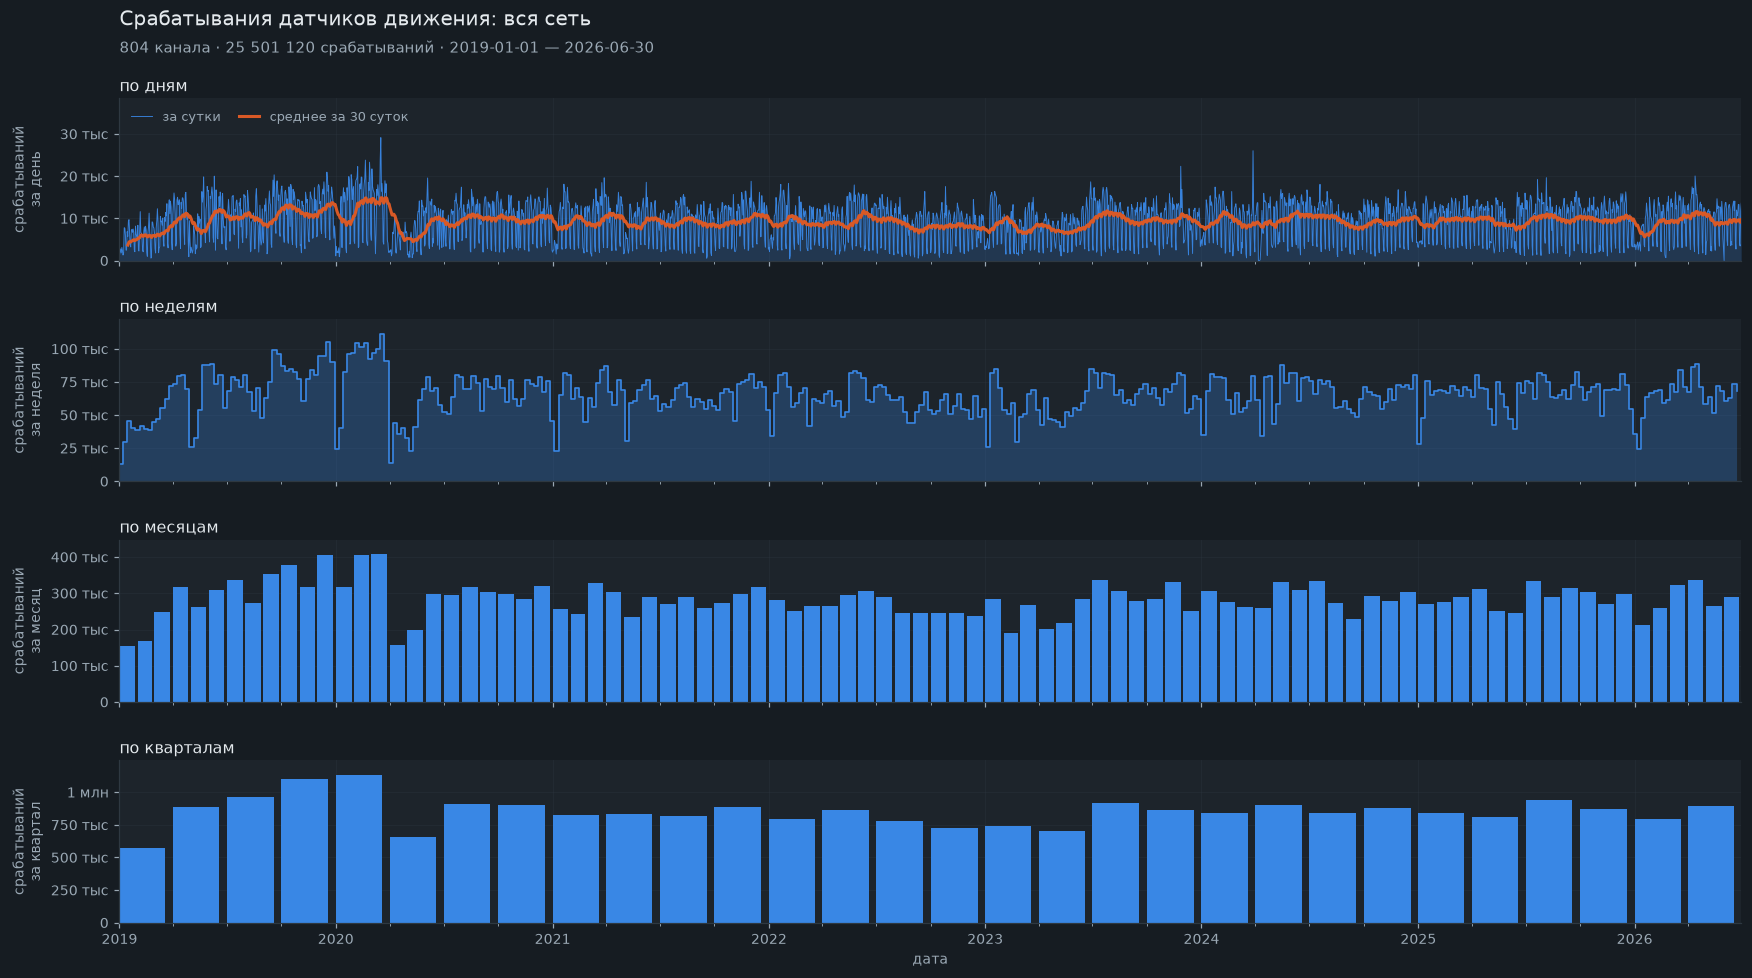

In [6]:
mo_all = roll_up(all_s, "MS")
qr_all = roll_up(all_s, "QS")
print("месяцев:", len(mo_all), "| кварталов:", len(qr_all),
      "| недель:", len(roll_up(all_s, "W-MON")))
print("самый сильный месяц:", mo_all.idxmax().date(), spaced(int(mo_all.max())))
print("март 2020:", spaced(int(mo_all["2020-03-01"])),
      "| апрель 2020:", spaced(int(mo_all["2020-04-01"])),
      f"| падение {100 * (1 - mo_all['2020-04-01'] / mo_all['2020-03-01']):.0f} %")
print("самый сильный квартал:", qr_all.idxmax().date(), spaced(int(qr_all.max())))

fig = interval_figure(
    all_s,
    "Срабатывания датчиков движения: вся сеть",
    f"804 канала · {spaced(int(all_s.sum()))} срабатываний · "
    f"{D0.date()} — {D1.date()}")
plt.show()

Что видно.

1. **Уровень держится.** После 2021 года квартал даёт от 0,7 до 0,9 млн
   срабатываний без тренда. Поток не растёт и не гаснет.
2. **Пик приходится на I квартал 2020 года**, 1 131 288 срабатываний, а самый
   сильный месяц — март 2020 года с 407 231.
3. **Апрель 2020 года обрывает пик**: 158 503 против 407 231 в марте, падение
   на 61 %. Дата совпадает с нерабочими днями по коронавирусу. Люди перестали
   ходить по объектам, датчики это записали.
4. **Дневной график выглядит гребёнкой.** Это не шум, а рабочая неделя.
   Проверяем следующей ячейкой.

### 2.2. Гребёнку даёт рабочая неделя

Среднее за сутки по дню недели. Если гребёнку даёт неделя, выходные будут
заметно ниже.

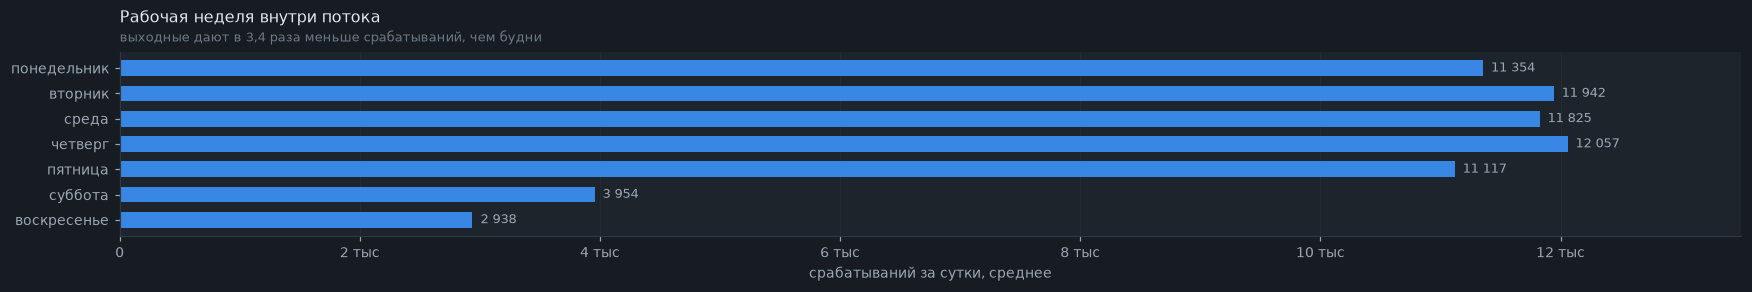

будни, среднее: 11 659 | выходные, среднее: 3 446 | отношение 3.4


In [7]:
DOW = ["понедельник", "вторник", "среда", "четверг", "пятница", "суббота", "воскресенье"]
dow = all_s.groupby(all_s.index.dayofweek).mean()

fig, ax = plt.subplots(figsize=(16, 2.8))
ax.barh(range(7), dow.values, color=SERIES[0], height=0.62)
ax.set_yticks(range(7), DOW)
ax.invert_yaxis()
ax.set_xlabel("срабатываний за сутки, среднее")
ax.xaxis.set_major_formatter(plt.FuncFormatter(human))
ax.grid(True, axis="x")
ax.grid(False, axis="y")
for i, v in enumerate(dow.values):
    ax.text(v, i, "  " + spaced(int(v)), va="center", color=DIM, fontsize=8.5)
ax.set_xlim(0, dow.max() * 1.12)
ax.text(0, 1.14, "Рабочая неделя внутри потока", transform=ax.transAxes,
        color=TEXT, fontsize=10.5, va="bottom")
ax.text(0, 1.04, "выходные дают в 3,4 раза меньше срабатываний, чем будни",
        transform=ax.transAxes, color=MUTE, fontsize=8.5, va="bottom")
plt.tight_layout(); plt.show()

print("будни, среднее:", spaced(int(dow[:5].mean())),
      "| выходные, среднее:", spaced(int(dow[5:].mean())),
      f"| отношение {dow[:5].mean() / dow[5:].mean():.1f}")

Будний день даёт в среднем 11 659 срабатываний, выходной — 3 446. Разница в
3,4 раза, и она объясняет всю гребёнку на дневном графике.

Отсюда практическое правило для модели: **признак дня недели обязателен**, а
недельное окно снимает этот ритм само.

### 2.3. Сеть росла, и это ломает сумму по сети

Сумма по всей сети складывает два разных изменения: сколько датчиков работает и
как часто каждый срабатывает. Считаем первое: сколько разных каналов дало хотя
бы одно срабатывание за месяц.

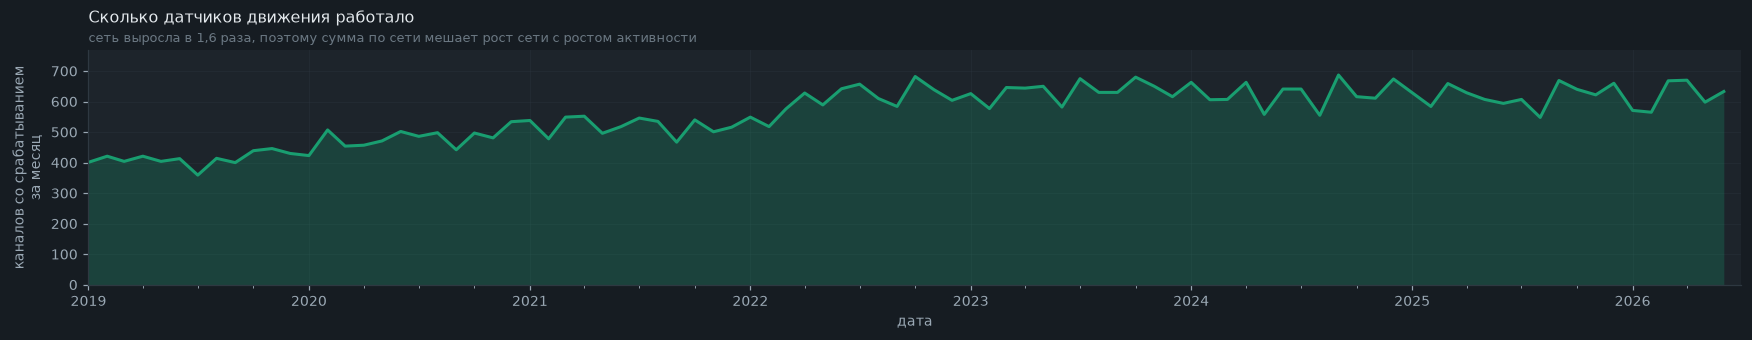

каналов в январе 2019: 401 | в июне 2026: 633 | рост 1.6
минимум за месяц: 359 | максимум: 687 | всего в справочнике: 804


In [8]:
live = con.sql(f"""
SELECT date_trunc('month', e.d) AS m,
       count(DISTINCT e.channel_id) AS каналов
FROM ev e JOIN ch c ON c.ид_канала_данных = e.channel_id
WHERE c.тип_датчика = '{SENSOR}' AND e.value = '{HIT}'
GROUP BY 1 ORDER BY 1
""").df()
act = pd.Series(live.каналов.values, index=pd.DatetimeIndex(live.m))

fig, ax = plt.subplots(figsize=(16, 3.2))
ax.fill_between(act.index, act.values, color=SERIES[2], alpha=0.25, lw=0)
ax.plot(act.index, act.values, color=SERIES[2], lw=2)
ax.set_ylim(0, act.max() * 1.12)
dress(ax, "каналов со срабатыванием\nза месяц",
      "Сколько датчиков движения работало",
      "сеть выросла в 1,6 раза, поэтому сумма по сети мешает рост сети с ростом активности",
      xlabel=True)
plt.tight_layout(); plt.show()

print("каналов в январе 2019:", int(act.iloc[0]),
      "| в июне 2026:", int(act.iloc[-1]),
      f"| рост {act.iloc[-1] / act.iloc[0]:.1f}")
print("минимум за месяц:", int(act.min()), "| максимум:", int(act.max()),
      "| всего в справочнике:", con.sql(
          f"SELECT count(*) FROM ch WHERE тип_датчика = '{SENSOR}'").fetchone()[0])

В январе 2019 года срабатывания дали 401 канал, в июне 2026 года — 633. Сеть
выросла в 1,6 раза, а сумма срабатываний по сети за это время не выросла. Значит
средний канал стал срабатывать реже, и сумма по сети этого не показывает.

Вывод для модели: **базовую ставку нельзя брать по сети.** Уровень сети меняется
вместе с составом сети, и «норма» для конкретного датчика в него не помещается.
Считать норму надо на канал. Дальше смотрим каналы по одному.

## 3. Отдельные датчики

Нужны каналы с длинной историей. Берём те, у которых срабатывания есть во все
восемь календарных годов выгрузки, и сортируем по числу суток с сигналом.

In [9]:
per_ch = con.sql(f"""
WITH m AS (
  SELECT e.channel_id AS cid, e.d
  FROM ev e JOIN ch c ON c.ид_канала_данных = e.channel_id
  WHERE c.тип_датчика = '{SENSOR}' AND e.value = '{HIT}'
), s AS (
  SELECT cid, count(*) AS срабатываний, count(DISTINCT d) AS суток,
         min(d) AS первое, max(d) AS последнее, count(DISTINCT year(d)) AS годов
  FROM m GROUP BY 1
)
SELECT s.cid AS канал, c.название_датчика AS датчик,
       o.диспетчерское_название_объекта AS объект,
       c.тег_инженерной_системы AS тег,
       s.срабатываний, s.суток,
       CAST(s.первое AS DATE) AS первое, CAST(s.последнее AS DATE) AS последнее
FROM s
JOIN ch c ON c.ид_канала_данных = s.cid
LEFT JOIN ob o ON o.ид_объект = c.ид_объект
WHERE s.годов = 8
ORDER BY s.суток DESC
""").df()

print("каналов с историей во все 8 годов:", len(per_ch), "из 804")
display(per_ch.head(12).style.format({"срабатываний": lambda v: spaced(int(v))})
        .hide(axis="index"))

каналов с историей во все 8 годов: 454 из 804


канал,датчик,объект,тег,срабатываний,суток,первое,последнее
3073,ОД пультовая ДП,ДП объект Вита,16-1.1.101.3.,2 077 321,2661,2019-01-02 00:00:00,2026-06-30 00:00:00
3084,ОД вход ДП,ДП объект Вита,16-1.1.104.1.,367 103,2632,2019-01-01 00:00:00,2026-06-30 00:00:00
3077,ОД комната отдыха ДП,ДП объект Вита,16-1.1.102.4.,842 192,2618,2019-01-01 00:00:00,2026-06-30 00:00:00
3082,ОД комната рабочих ДП,ДП объект Вита,16-1.1.103.4.,512 677,2574,2019-01-03 00:00:00,2026-06-30 00:00:00
196499,ОД ДП 1 эт вход,ДП объект Альфа,797-1.1.117.2.,393 865,2559,2019-01-02 00:00:00,2026-06-30 00:00:00
196503,ОД ДП 1 эт. ком.техника,ДП объект Альфа,797-1.1.118.1.,565 872,2557,2019-01-02 00:00:00,2026-06-30 00:00:00
196491,ОД ДП 1 эт зап.вход,ДП объект Альфа,797-1.1.115.4.,181 449,2533,2019-01-02 00:00:00,2026-06-30 00:00:00
171558,ОД ДП Новые Черёмушки,ДП объект Эпсилон,672-1.1.55.2.,1 134 889,2520,2019-01-01 00:00:00,2026-06-30 00:00:00
196480,ОД ДП 1 эт ком. отдыха,ДП объект Альфа,797-1.1.113.5.,509 322,2437,2019-01-02 00:00:00,2026-06-30 00:00:00
197729,ОД ком.техника,ДП объект Эпсилон,672-1.1.68.4.,455 667,2414,2019-01-01 00:00:00,2026-06-30 00:00:00


Из 454 таких каналов берём четыре. Отбор не по одному объёму: нужны разные
объекты и разные рисунки поведения.

| Канал | Датчик | Почему взят |
|---|---|---|
| 3073 | ОД пультовая ДП | самый плотный поток сети, 2 661 сутки с сигналом |
| 171558 | ОД ДП Новые Черёмушки | поток растёт весь период |
| 196503 | ОД ДП 1 эт. ком.техника | средний объём, поток медленно гаснет |
| 209989 | ОД подв+вх в коллект | вход в коллектор, резкая смена режима |

Каждый канал получает те же четыре масштаба и свой цвет из набора.

In [10]:
PICK = [3073, 171558, 196503, 209989]

daily_pick = con.sql(f"""
SELECT e.channel_id AS cid, e.d AS d, count(*) AS n
FROM ev e JOIN ch c ON c.ид_канала_данных = e.channel_id
WHERE c.тип_датчика = '{SENSOR}' AND e.value = '{HIT}'
  AND e.channel_id IN ({', '.join(str(c) for c in PICK)})
GROUP BY 1, 2 ORDER BY 1, 2
""").df()

meta = per_ch.set_index("канал")
pick_s = {cid: as_daily(g.d, g.n)
          for cid, g in daily_pick.groupby("cid")}

rows = []
for cid in PICK:
    s, mo = pick_s[cid], roll_up(pick_s[cid], "MS")
    zero = (s == 0).astype(int)
    rows.append({
        "канал": cid,
        "датчик": meta.loc[cid, "датчик"],
        "объект": meta.loc[cid, "объект"],
        "срабатываний": int(s.sum()),
        "суток с сигналом": int((s > 0).sum()),
        "медиана месяца до 10.2023": int(mo[:"2023-09"].median()),
        "медиана месяца после": int(mo["2023-10":].median()),
        "сильнейший месяц": f"{mo.idxmax():%Y-%m}",
        "срабатываний в нём": int(mo.max()),
        "макс. пауза, суток": int(zero.groupby((zero != zero.shift()).cumsum()).sum().max()),
    })
summary = pd.DataFrame(rows)
cols = ["срабатываний", "срабатываний в нём",
        "медиана месяца до 10.2023", "медиана месяца после"]
display(summary.style.format({c: lambda v: spaced(int(v)) for c in cols})
        .hide(axis="index"))

канал,датчик,объект,срабатываний,суток с сигналом,медиана месяца до 10.2023,медиана месяца после,сильнейший месяц,срабатываний в нём,"макс. пауза, суток"
3073,ОД пультовая ДП,ДП объект Вита,2 077 321,2661,27 860,15 557,2020-12,49 172,5
171558,ОД ДП Новые Черёмушки,ДП объект Эпсилон,1 134 889,2520,8 876,18 316,2026-04,31 934,5
196503,ОД ДП 1 эт. ком.техника,ДП объект Альфа,565 872,2557,7 061,4 701,2020-02,12 710,21
209989,ОД подв+вх в коллект,ДП объект Йота,445 226,1766,1 492,8 495,2023-11,16 397,52


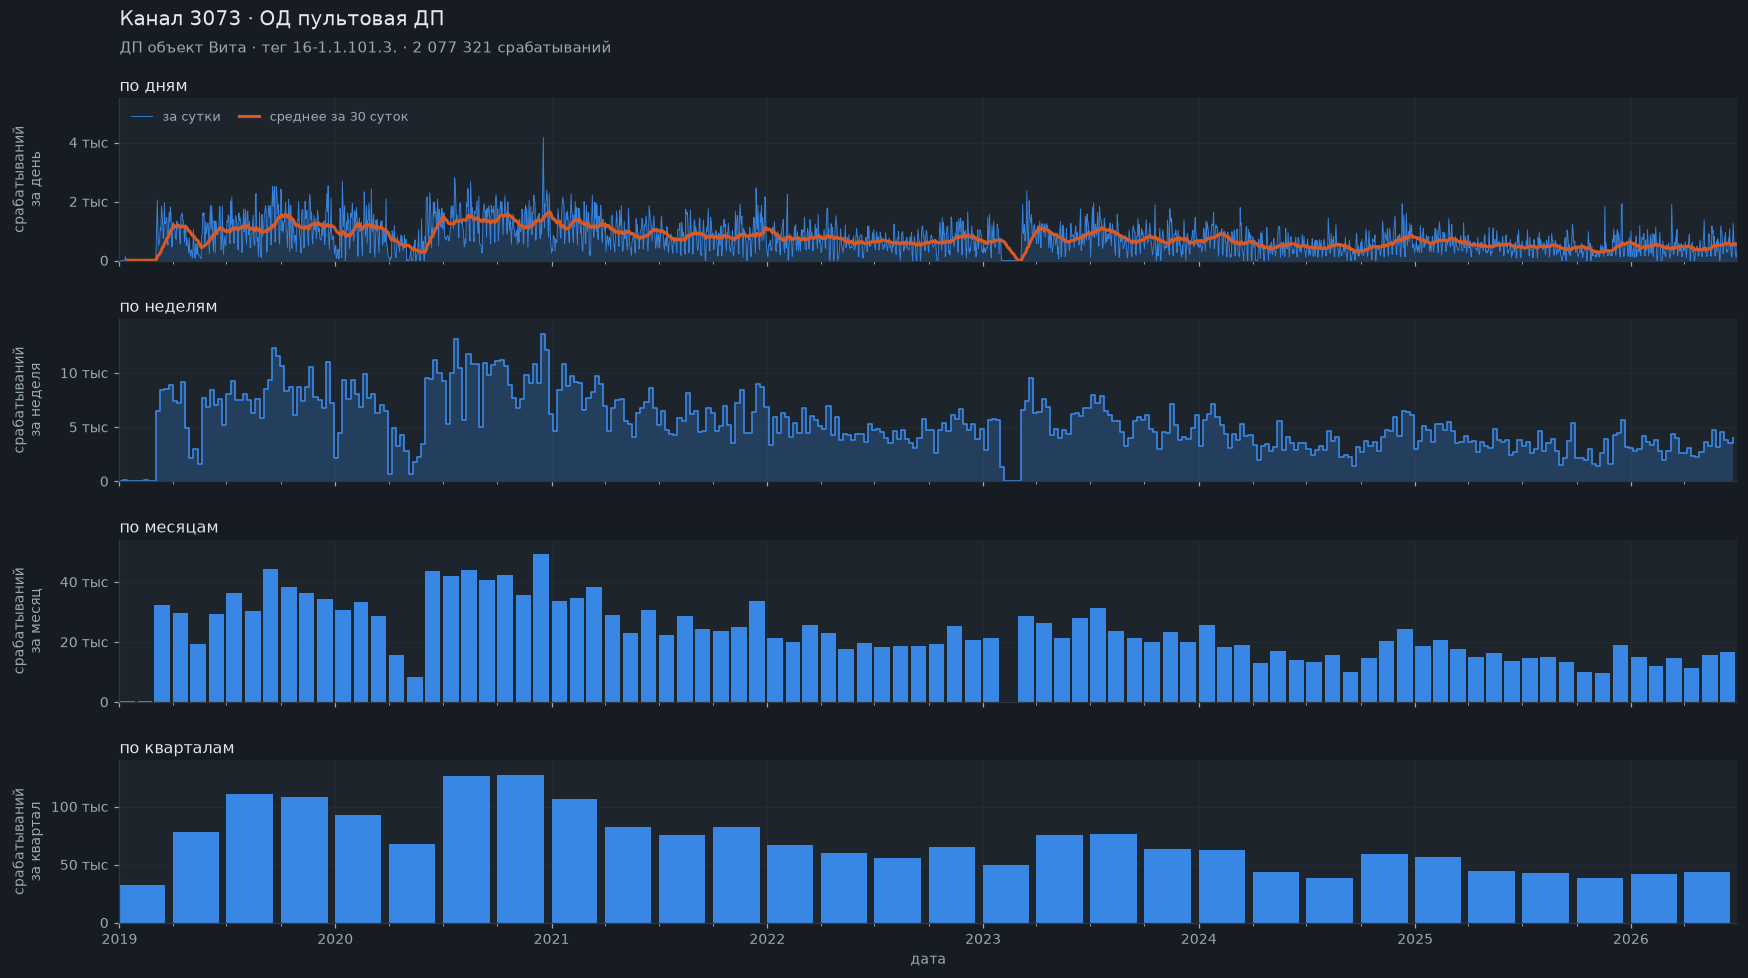

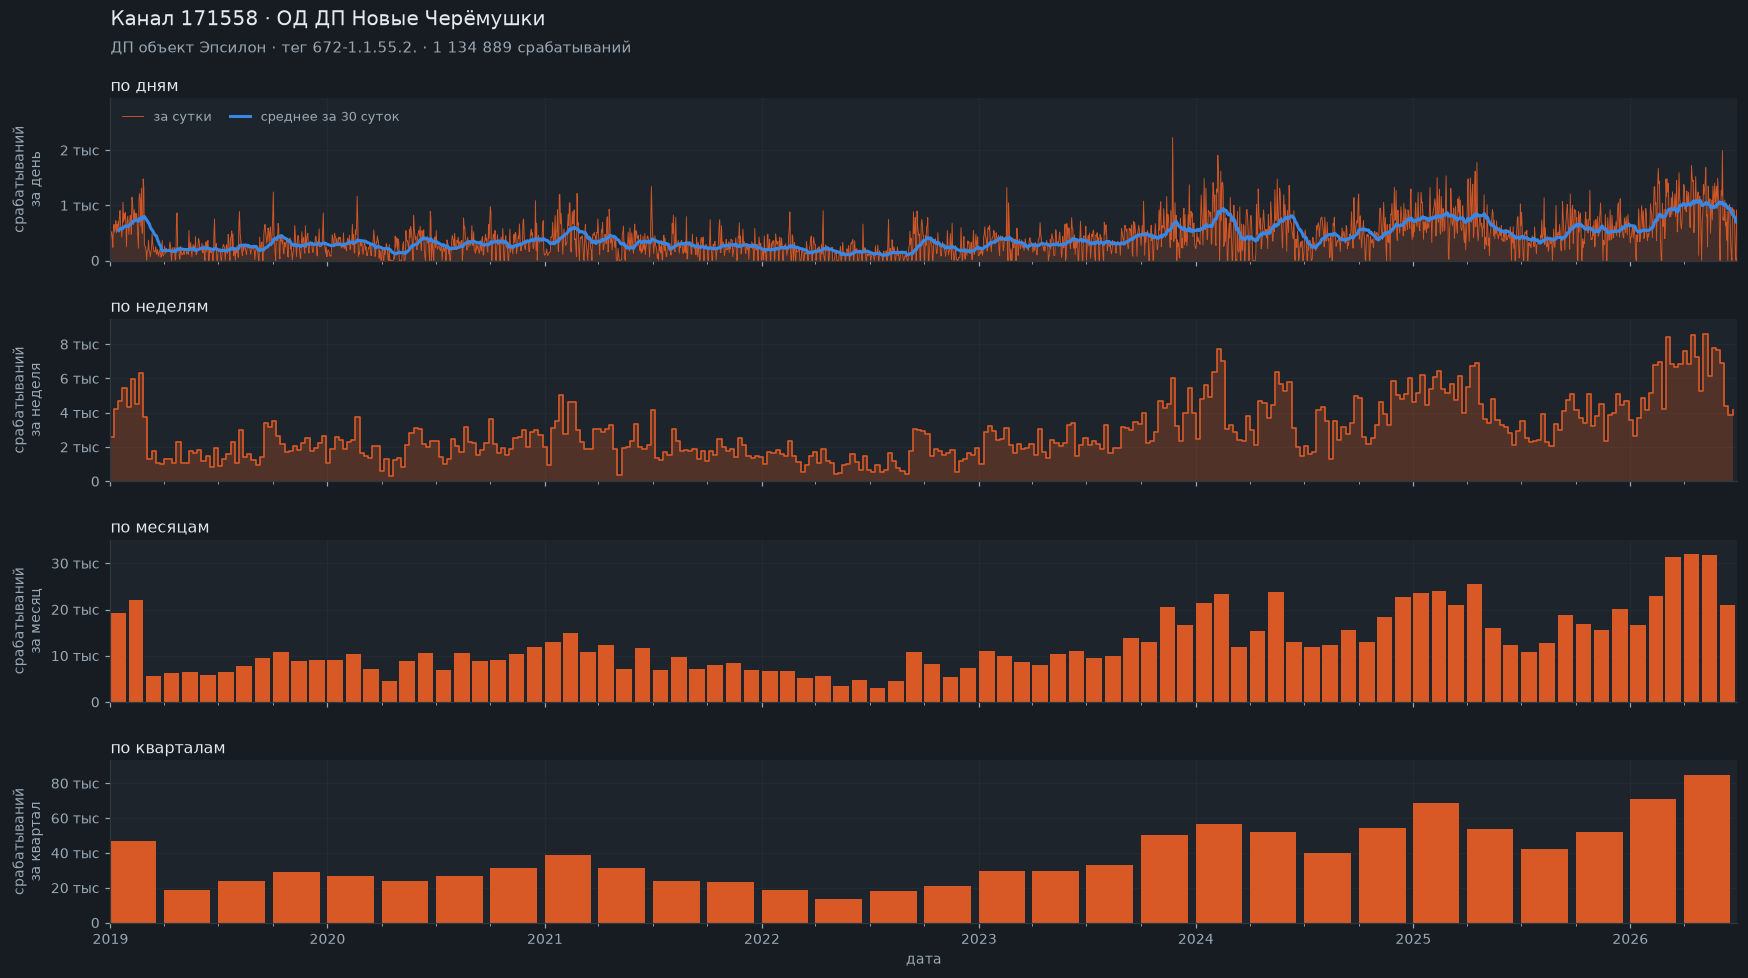

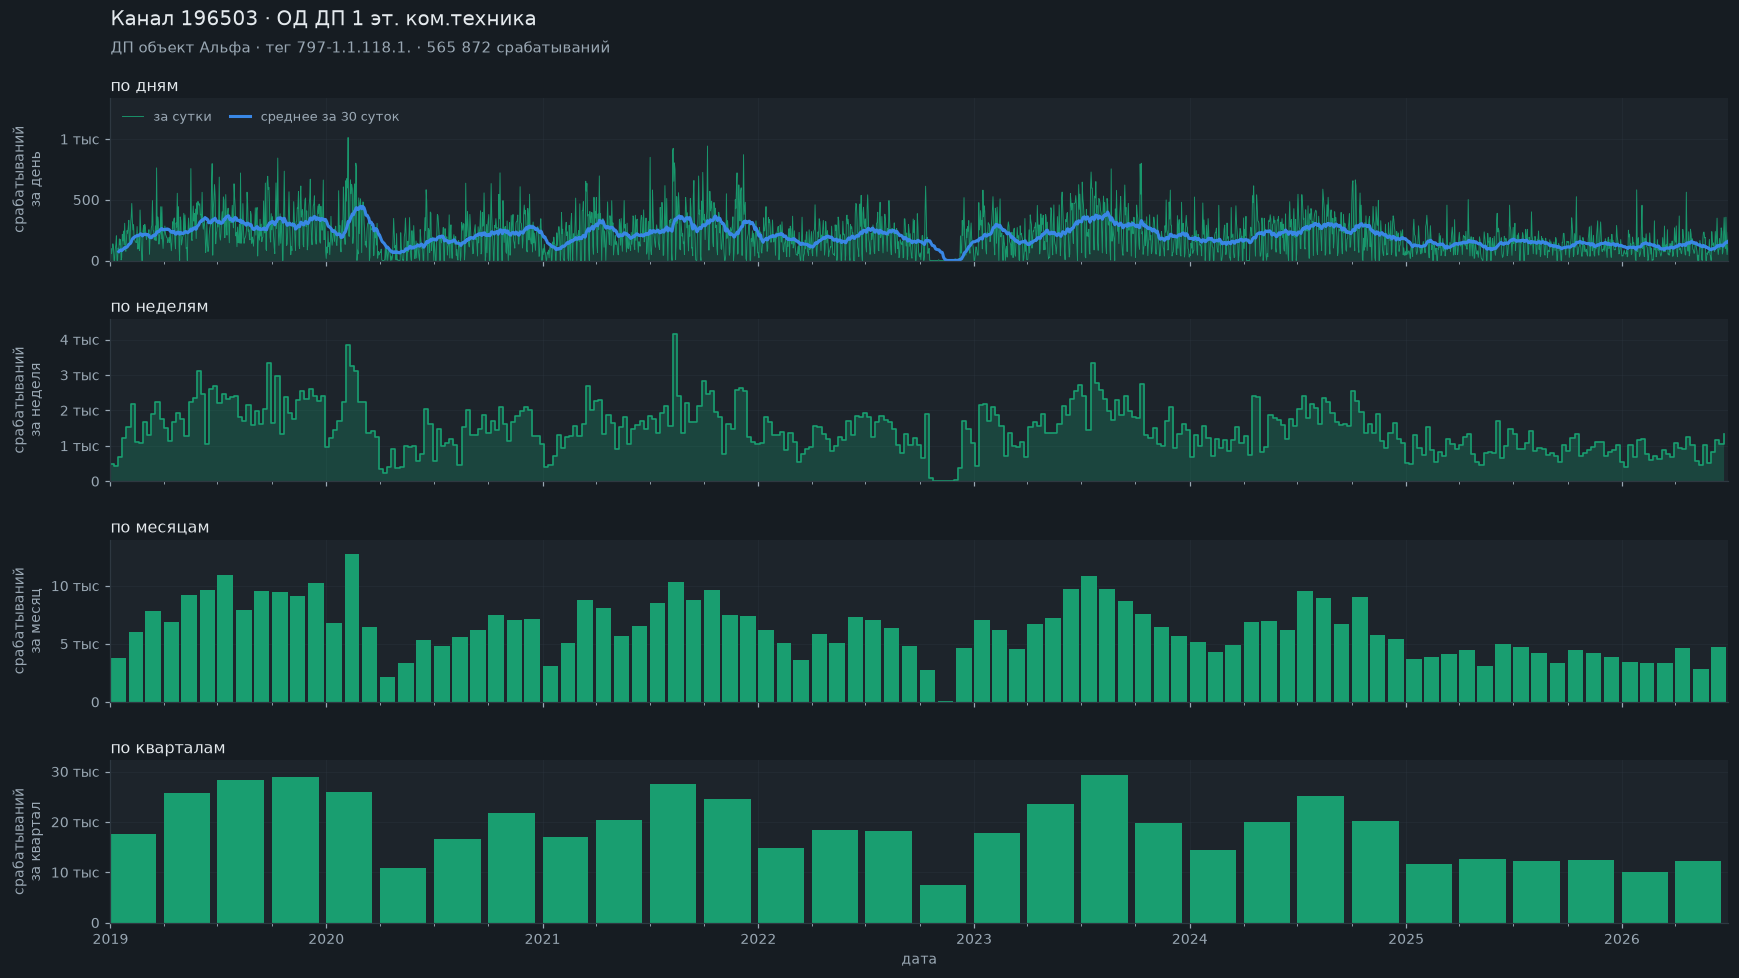

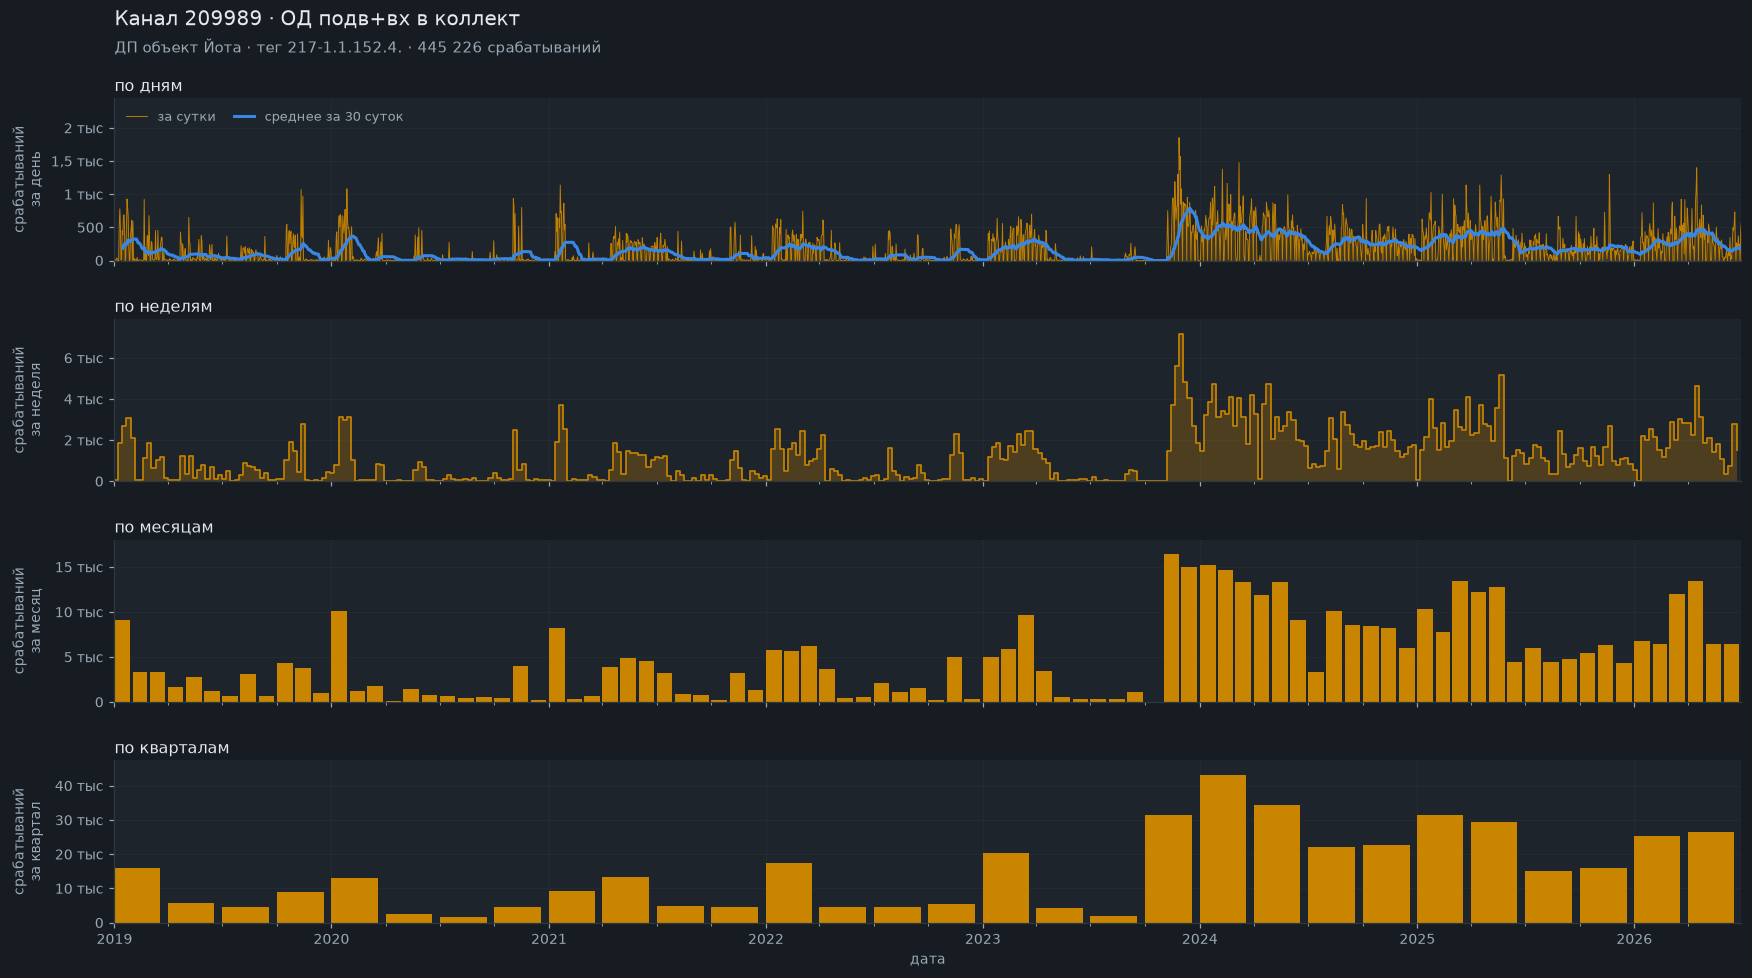

In [11]:
for i, cid in enumerate(PICK):
    s = pick_s[cid]
    fig = interval_figure(
        s,
        f"Канал {cid} · {meta.loc[cid, 'датчик']}",
        f"{meta.loc[cid, 'объект']} · тег {meta.loc[cid, 'тег']} · "
        f"{spaced(int(s.sum()))} срабатываний",
        color=SERIES[i])
    plt.show()

Четыре канала одного типа ведут себя по-разному.

- **3073, пультовая ДП.** Поток гаснет: медиана месяца падает с 27 860 до
  15 557. Пауз почти нет, максимум 5 суток подряд.
- **171558, ДП Новые Черёмушки.** Поток растёт вдвое: медиана месяца идёт с
  8 876 до 18 316, и сильнейший месяц приходится на апрель 2026 года.
- **196503, ком.техника.** Медленный спад с 7 061 до 4 701 и пауза длиной
  21 сутки.
- **209989, вход в коллектор.** Резкая смена режима осенью 2023 года: медиана
  месяца прыгает с 1 492 до 8 495, почти в шесть раз. Максимальная пауза
  канала — 52 суток, и она приходится на время до скачка.

Скачок на 209989 виден во всех четырёх масштабах. Пауза длиной 52 суток видна на
дневном и недельном, а на квартальном пропадает совсем. Отсюда правило: **шаг
агрегации скрывает то, что короче шага.** Дневной ряд показывает паузы и
выбросы, квартальный — уровень.

### 3.1. Четыре канала на одной шкале

Месячная сумма, общая ось. Легенда снизу, номер канала подписан прямо у конца
линии: цвет не единственный ключ к ряду.

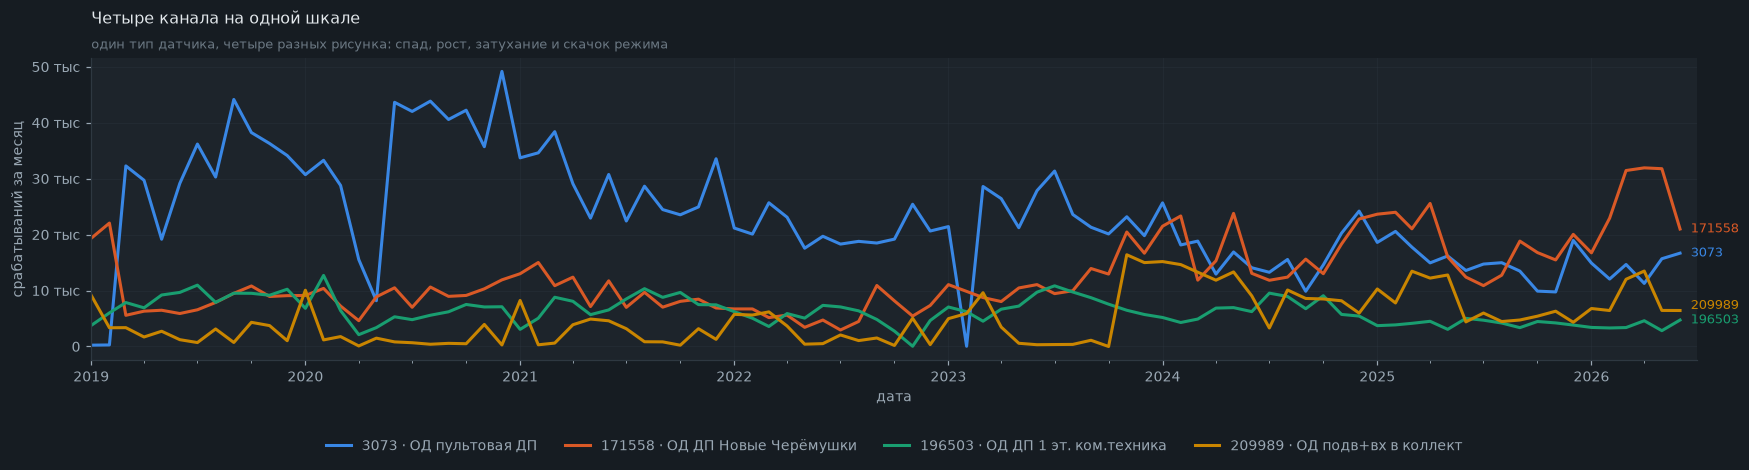

In [12]:
fig, ax = plt.subplots(figsize=(16, 4.6))
ends = {}
for i, cid in enumerate(PICK):
    r = roll_up(pick_s[cid], "MS")
    ax.plot(r.index, r.values, color=SERIES[i], lw=2,
            label=f"{cid} · {meta.loc[cid, 'датчик']}")
    ends[cid] = (r.index[-1], float(r.values[-1]), SERIES[i])

# подписи у конца линий расходятся по вертикали, иначе близкие ряды слипаются
gap, prev = ax.get_ylim()[1] * 0.05, None
for cid, (x, y, col) in sorted(ends.items(), key=lambda kv: kv[1][1]):
    if prev is not None and y - prev < gap:
        y = prev + gap
    prev = y
    ax.annotate(str(cid), (x, y), xytext=(7, 0), textcoords="offset points",
                color=col, fontsize=8.5, va="center", annotation_clip=False)

dress(ax, "срабатываний за месяц", "Четыре канала на одной шкале",
      "один тип датчика, четыре разных рисунка: спад, рост, затухание и скачок режима",
      xlabel=True)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=4,
          labelcolor=DIM, fontsize=9, handlelength=1.8)
plt.tight_layout(); plt.show()

## Выводы

1. Срабатывание датчика движения — это запись «Обнаружено движение». Их
   25 501 120 за период с 1 января 2019 по 30 июня 2026 года.
2. Поток по сети держит уровень 0,7–0,9 млн за квартал. Тренда нет.
3. Два внешних события видны прямо на графике: пик I квартала 2020 года и
   обвал апреля 2020 года на 61 %.
4. Рабочая неделя даёт ритм силой 3,4 раза между буднями и выходными. Признак
   дня недели для модели обязателен.
5. Сумма по сети смешивает рост сети с ростом активности. Норму надо считать на
   канал, а не на сеть.
6. Каналы одного типа ведут себя по-разному: один гаснет, другой растёт вдвое,
   третий медленно затухает, четвёртый меняет режим почти в шесть раз. Модель с
   одним порогом на тип датчика такие каналы не разделит.
7. Шаг агрегации скрывает то, что короче шага. Пауза длиной 52 суток есть на
   дневном ряде и пропадает на квартальном.

Что из этого идёт в работу: признак дня недели, норма на канал и поиск смены
режима как отдельный признак. Разбор направления «несанкционированный доступ»
лежит в `hackathon-gap-analysis.md`.